# Rayleigh–Benard Convection

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
import h5py
import torch
import random
import numpy as np
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## CAE

In [4]:
def compute_buoyancy_flux(b, vel):
    u_y = vel[..., 1]
    b_bar = b.mean(axis=-2, keepdims=True)
    return u_y * (b - b_bar)

In [7]:
paths_train = sorted(glob.glob("data/data/train/rayleigh_benard_Rayleigh_1e8_Prandtl_1.hdf5"))
paths_valid = sorted(glob.glob("data/data/valid/rayleigh_benard_Rayleigh_1e8_Prandtl_1.hdf5"))
train_path = paths_train[0]
valid_path = paths_valid[0]

In [9]:
class RBCDataset(Dataset):
    def __init__(self, h5_path, trajectories=None, time_indices=None):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, "r") as f:
            self.b_ds = "t0_fields/buoyancy"
            self.v_ds = "t1_fields/velocity"
            b_shape = f[self.b_ds].shape
            self.n_traj, self.n_time, self.nx, self.ny = b_shape
        self.traj_indices = list(range(self.n_traj)) if trajectories is None else list(trajectories)
        self.time_indices = list(range(self.n_time)) if time_indices is None else list(time_indices)
        self.index_pairs = [(ti, tj) for ti in self.traj_indices for tj in self.time_indices]

    def __len__(self):
        return len(self.index_pairs)

    def __getitem__(self, idx):
        traj_idx, t_idx = self.index_pairs[idx]
        with h5py.File(self.h5_path, "r") as f:
            b = f[self.b_ds][traj_idx, t_idx]
            vel = f[self.v_ds][traj_idx, t_idx]
        j_b = compute_buoyancy_flux(b, vel)
        return torch.from_numpy(j_b).float().unsqueeze(0)

In [10]:
train_dataset = RBCDataset(train_path)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
next(iter(train_loader)).shape

torch.Size([32, 1, 512, 128])

In [28]:
class CAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 256, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(128, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(64, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(32, 32, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(32, 8, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 32, (1, 2), (1, 2)),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 32, (1, 2), (1, 2)),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 64, (1, 2), (1, 2)),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 128, (1, 2), (1, 2)),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 256, (1, 2), (1, 2)),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 1, (1, 2), (1, 2)),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec

In [29]:
cae = CAE().to(device)
optimizer = optim.AdamW(cae.parameters(), lr=1e-3)
criterion = nn.MSELoss()
epochs = 10

for epoch in tqdm(range(epochs), desc="Epoch"):
    cae.train()
    loss_sum = 0.0
    for x in train_loader:
        x = x.to(device)
        x_rec = cae(x)
        loss = criterion(x_rec, x)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_sum += loss.item() * x.size(0)
    print(f"Epoch {epoch}: train_loss={loss_sum / len(train_dataset):.4e}")

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch:  10%|█         | 1/10 [00:44<06:37, 44.19s/it]

Epoch 0: train_loss=1.3420e-03


Epoch:  20%|██        | 2/10 [01:27<05:50, 43.86s/it]

Epoch 1: train_loss=1.9362e-04


...

Epoch 7: train_loss=3.2245e-05


Epoch:  90%|█████████ | 9/10 [06:36<00:44, 44.01s/it]

Epoch 8: train_loss=3.0047e-05


Epoch: 100%|██████████| 10/10 [07:20<00:00, 44.04s/it]

Epoch 9: train_loss=2.8729e-05


In [30]:
val_dataset = RBCDataset(valid_path)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True, num_workers=0)

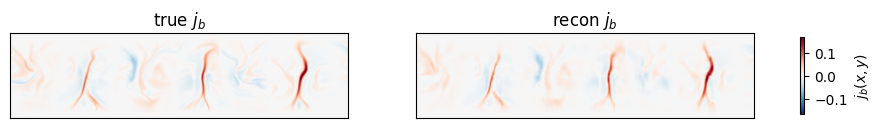

In [31]:
sample = next(iter(val_loader)).to(device)
cae.eval()
with torch.no_grad():
    recon = cae(sample)
frames = sample[0, 0].cpu().numpy()
recon_f = recon[0, 0].cpu().numpy()
m = np.nanmax(np.abs(np.stack([frames, recon_f], axis=0)))
norm = plt.Normalize(vmin=-m, vmax=m)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im = axs[0].imshow(frames.T, cmap="RdBu_r", norm=norm, origin="lower")
axs[0].set_xticks([])
axs[0].set_yticks([])
axs[0].set_title("true $j_b$")
axs[1].imshow(recon_f.T, cmap="RdBu_r", norm=norm, origin="lower")
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_title("recon $j_b$")
cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.2)
cbar.set_label(r"$j_b(x,y)$")
# plt.tight_layout()
plt.show()

## RNN

Let's consider two cases, as it is in the original paper.

### ESN

In [16]:
class RBCPairsDataset(Dataset):
    def __init__(self, h5_path, trajectories=None):
        self.h5_path = h5_path
        with h5py.File(self.h5_path, "r") as f:
            self.b_ds = "t0_fields/buoyancy"
            self.v_ds = "t1_fields/velocity"
            b_shape = f[self.b_ds].shape
            self.n_traj, self.n_time, self.nx, self.ny = b_shape
        self.traj_indices = list(range(self.n_traj)) if trajectories is None else list(trajectories)
        self.index_pairs = [(ti, t) for ti in self.traj_indices for t in range(self.n_time - 1)]

    def __len__(self):
        return len(self.index_pairs)

    def __getitem__(self, idx):
        traj_idx, t_idx = self.index_pairs[idx]
        t_next = t_idx + 1
        with h5py.File(self.h5_path, "r") as f:
            b_t = f[self.b_ds][traj_idx, t_idx]
            v_t = f[self.v_ds][traj_idx, t_idx]
            b_tp1 = f[self.b_ds][traj_idx, t_next]
            v_tp1 = f[self.v_ds][traj_idx, t_next]
        j_t = compute_buoyancy_flux(b_t, v_t)
        j_tp1 = compute_buoyancy_flux(b_tp1, v_tp1)
        is_first = t_idx == 0
        return (
            torch.from_numpy(j_t).float().unsqueeze(0),
            torch.from_numpy(j_tp1).float().unsqueeze(0),
            traj_idx,
            is_first,
        )

In [17]:
class ESN:
    def __init__(self, input_dim, reservoir_size=500, density=0.05, spectral_radius=0.9, leak_rate=0.3, ridge_beta=1e-5, random_state=42):
        self.input_dim = input_dim
        self.reservoir_size = reservoir_size
        self.density = density
        self.spectral_radius = spectral_radius
        self.leak_rate = leak_rate
        self.ridge_beta = ridge_beta
        self.rng = np.random.RandomState(random_state)
        self.W_in = self.rng.uniform(-1, 1, size=(reservoir_size, input_dim))
        W = self.rng.uniform(-1, 1, size=(reservoir_size, reservoir_size))
        mask = self.rng.rand(reservoir_size, reservoir_size) < density
        W *= mask.astype(np.float32)
        eigvals = np.linalg.eigvals(W)
        radius = np.max(np.abs(eigvals))
        if radius > 0:
            W *= spectral_radius / radius
        self.W_res = W.astype(np.float32)
        self.W_out = None

    def _update(self, r_prev, c_t):
        pre = self.W_in @ c_t + self.W_res @ r_prev
        r_tilde = np.tanh(pre)
        return (1.0 - self.leak_rate) * r_prev + self.leak_rate * r_tilde

    def fit_from_pairs(self, C_prev, C_next, reset_flags):
        M, D = C_prev.shape
        N = self.reservoir_size
        R_list, C_list = [], []
        r = np.zeros(N, dtype=np.float32)
        for i in range(M):
            if reset_flags[i]:
                r = np.zeros(N, dtype=np.float32)
            r = self._update(r, C_prev[i])
            R_list.append(r.copy())
            C_list.append(C_next[i].copy())
        R = np.stack(R_list, axis=0)
        C = np.stack(C_list, axis=0)
        RtR = R.T @ R
        A = RtR + self.ridge_beta * np.eye(N, dtype=np.float32)
        RtC = R.T @ C
        W_out_T = np.linalg.solve(A, RtC)
        self.W_out = W_out_T.T.astype(np.float32)

    def rollout(self, c0, steps):
        assert self.W_out is not None
        N = self.reservoir_size
        r = np.zeros(N, dtype=np.float32)
        c_prev = c0.copy()
        preds = []
        for _ in range(steps):
            r = self._update(r, c_prev)
            c_next = self.W_out @ r
            preds.append(c_next.copy())
            c_prev = c_next
        return np.stack(preds, axis=0)

In [32]:
pairs_dataset = RBCPairsDataset(train_path)
C_prev_list, C_next_list, reset_list = [], [], []
cae.eval()

for i in tqdm(range(len(pairs_dataset)), desc="Latents"):
    j_t, j_tp1, traj_idx, is_first = pairs_dataset[i]
    j_t = j_t.unsqueeze(0).to(device)
    j_tp1 = j_tp1.unsqueeze(0).to(device)
    with torch.no_grad():
        z_t = cae.encoder(j_t)
        z_tp1 = cae.encoder(j_tp1)
    z_t_flat = z_t.view(1, -1)[0].cpu().numpy()
    z_tp1_flat = z_tp1.view(1, -1)[0].cpu().numpy()
    C_prev_list.append(z_t_flat)
    C_next_list.append(z_tp1_flat)
    reset_list.append(is_first)

C_prev = np.stack(C_prev_list, axis=0)
C_next = np.stack(C_next_list, axis=0)
reset_flags = np.array(reset_list, dtype=bool)
latent_dim = C_prev.shape[1]

Latents:   0%|          | 14/7960 [00:00<00:57, 138.37it/s]

Latents: 100%|██████████| 7960/7960 [00:51<00:00, 153.50it/s]


In [41]:
esn = ESN(
    input_dim=latent_dim,
    reservoir_size=2048,
    density=0.1,
    spectral_radius=0.97,
    leak_rate=0.5,
    ridge_beta=5.0,
    random_state=42
)
esn.fit_from_pairs(C_prev, C_next, reset_flags)

In [42]:
def visualize_true_vs_pred(jb_true, jb_pred, time_indices=None):
    T, X, Y = jb_true.shape
    if time_indices is None:
        time_indices = [0, T // 3, (2 * T) // 3, T - 1]
    m = np.nanmax(np.abs(np.concatenate([jb_true, jb_pred], axis=0)))
    norm = plt.Normalize(vmin=-m, vmax=m)
    fig, axs = plt.subplots(2, len(time_indices), figsize=(5 * len(time_indices), 6), dpi=120)
    for i, t_idx in enumerate(time_indices):
        ax = axs[0, i]
        im = ax.imshow(jb_true[t_idx].T, cmap="RdBu_r", norm=norm, origin="lower")
        ax.set_title(f"true $j_b$, t={t_idx}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax = axs[1, i]
        ax.imshow(jb_pred[t_idx].T, cmap="RdBu_r", norm=norm, origin="lower")
        ax.set_title(f"pred $j_b$, t={t_idx}")
        ax.set_xticks([])
        ax.set_yticks([])
    cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.5, aspect=25)
    cbar.set_label(r"$j_b(x,y)$")
    # plt.tight_layout()
    plt.show()

In [43]:
with h5py.File(valid_path, "r") as f:
    b_val = f["t0_fields/buoyancy"][:]
    v_val = f["t1_fields/velocity"][:]

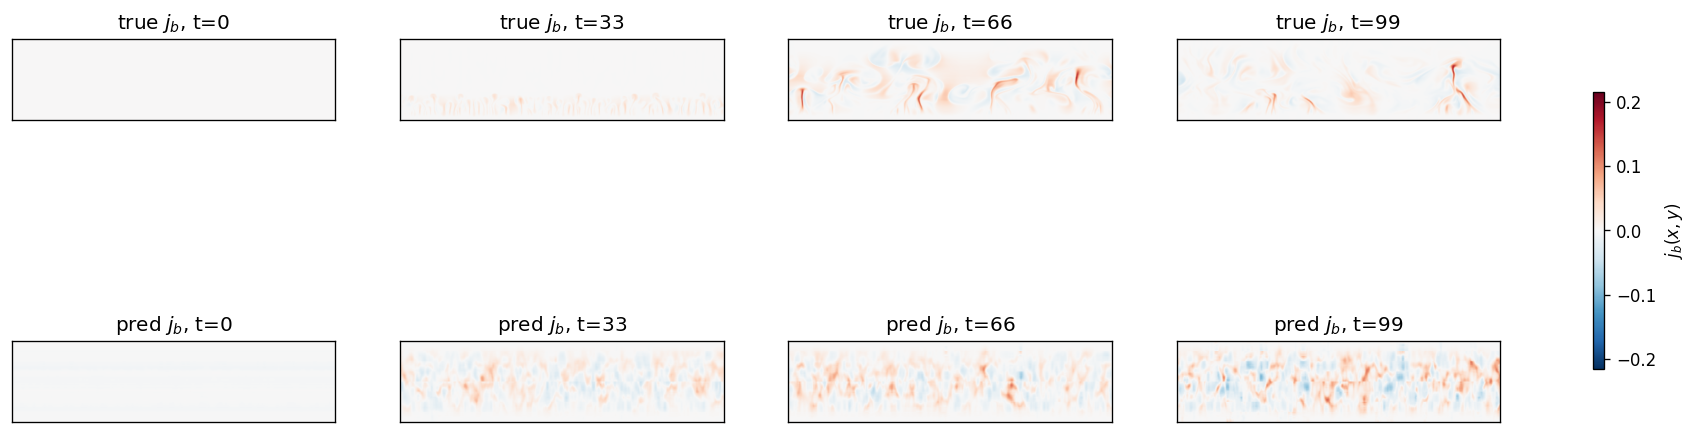

In [44]:
traj_idx = 0
b_traj = b_val[traj_idx]
v_traj = v_val[traj_idx]
jb_traj = compute_buoyancy_flux(b_traj, v_traj)
T, X, Y = jb_traj.shape
jb_tensor = torch.from_numpy(jb_traj).float().unsqueeze(1).to(device)
with torch.no_grad():
    z = cae.encoder(jb_tensor)
z_flat = z.view(T, -1).cpu().numpy()
steps = T // 2
c0 = z_flat[0]
c_pred = esn.rollout(c0, steps=steps)
c_pred_t = torch.from_numpy(c_pred).float().to(device)
latent_shape = z.shape[1:]
c_pred_t = c_pred_t.view(steps, *latent_shape)
with torch.no_grad():
    jb_pred_t = cae.decoder(c_pred_t).cpu().numpy()[:, 0]
jb_pred = jb_pred_t
jb_true = jb_traj[1:steps+1]
visualize_true_vs_pred(jb_true, jb_pred)

### LSTM

In [45]:
with h5py.File(train_path, "r") as f:
    b_train = f["t0_fields/buoyancy"][:]
    v_train = f["t1_fields/velocity"][:]

n_traj_train, T_train, nx, ny = b_train.shape

cae.eval()
latent_trajs = []

for traj_idx in tqdm(range(n_traj_train), desc="Latent trajs"):
    b_traj = b_train[traj_idx]
    v_traj = v_train[traj_idx]
    jb_traj = compute_buoyancy_flux(b_traj, v_traj)
    jb_tensor = torch.from_numpy(jb_traj).float().unsqueeze(1).to(device)
    with torch.no_grad():
        z = cae.encoder(jb_tensor)
    z_flat = z.view(T_train, -1).cpu()
    latent_trajs.append(z_flat)

latent_train = torch.stack(latent_trajs, dim=0)  # (N_traj, T, D)
N_traj, T_seq, D_latent = latent_train.shape

seq_dataset = torch.utils.data.TensorDataset(latent_train)
seq_loader = DataLoader(seq_dataset, batch_size=4, shuffle=True, num_workers=0)

Latent trajs: 100%|██████████| 40/40 [00:04<00:00,  8.16it/s]


In [46]:
class LatentLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, h=None):
        y, h = self.lstm(x, h)
        y = self.out(y)
        return y, h

In [54]:
lstm = LatentLSTM(D_latent, hidden_dim=2048, num_layers=1).to(device)
optimizer_lstm = optim.Adam(lstm.parameters(), lr=1e-4)
criterion_lstm = nn.MSELoss()
epochs_lstm = 100

for epoch in tqdm(range(epochs_lstm), desc="LSTM"):
    lstm.train()
    loss_sum = 0.0
    for (seq,) in seq_loader:
        seq = seq.to(device)
        inp = seq[:, :-1, :]
        target = seq[:, 1:, :]
        pred, _ = lstm(inp)
        loss = criterion_lstm(pred, target)
        loss.backward()
        optimizer_lstm.step()
        optimizer_lstm.zero_grad()
        loss_sum += loss.item() * seq.size(0)
    print(f"LSTM epoch {epoch}  loss={loss_sum / len(seq_dataset):.4e}")

LSTM:   1%|          | 1/100 [00:00<00:25,  3.83it/s]

LSTM epoch 0  loss=4.5144e+00


LSTM:   2%|▏         | 2/100 [00:00<00:25,  3.86it/s]

LSTM epoch 1  loss=2.2034e+00


LSTM:   3%|▎         | 3/100 [00:00<00:25,  3.88it/s]

...

LSTM epoch 97  loss=6.1385e-01


LSTM:  99%|█████████▉| 99/100 [00:25<00:00,  3.89it/s]

LSTM epoch 98  loss=6.1325e-01


LSTM: 100%|██████████| 100/100 [00:25<00:00,  3.89it/s]

LSTM epoch 99  loss=6.1182e-01


In [55]:
def rollout_lstm(model, c0, steps):
    model.eval()
    c_prev = torch.from_numpy(c0).float().unsqueeze(0).unsqueeze(0).to(device)
    h = None
    preds = []
    with torch.no_grad():
        for _ in range(steps):
            out, h = model.lstm(c_prev, h)
            c_next = model.out(out[:, -1])
            preds.append(c_next.cpu().numpy()[0])
            c_prev = c_next.unsqueeze(1)
    return np.stack(preds, axis=0)

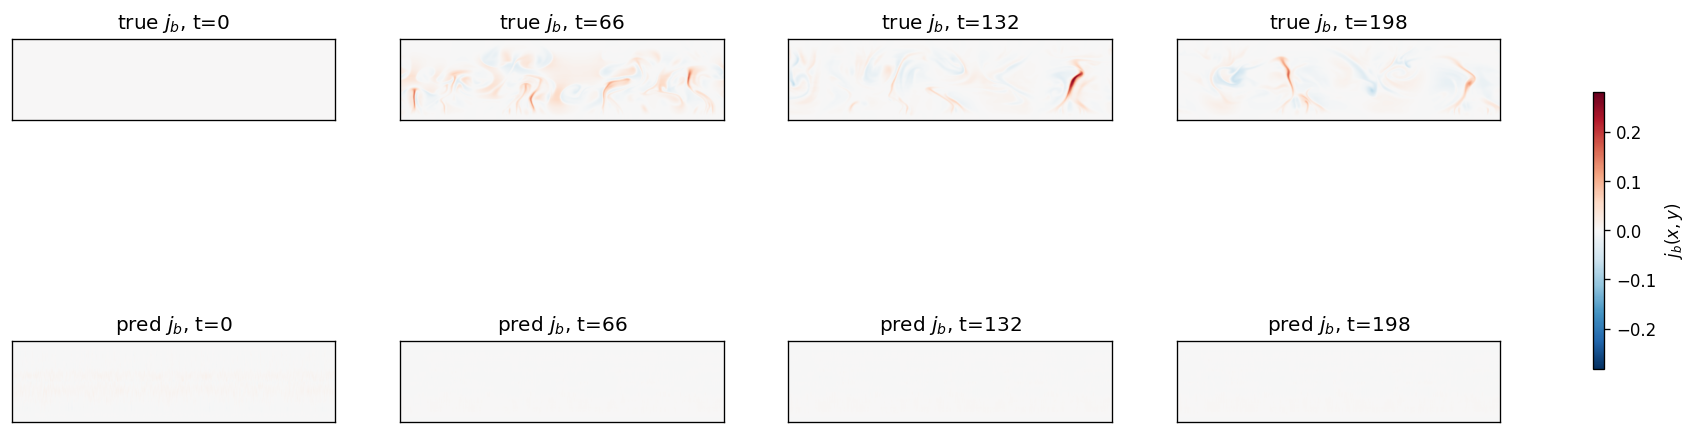

In [56]:
traj_idx_lstm = 0
b_traj_val = b_val[traj_idx_lstm]
v_traj_val = v_val[traj_idx_lstm]
jb_traj_val = compute_buoyancy_flux(b_traj_val, v_traj_val)
T_val, X_val, Y_val = jb_traj_val.shape

jb_tensor_val = torch.from_numpy(jb_traj_val).float().unsqueeze(1).to(device)
cae.eval()
with torch.no_grad():
    z_val = cae.encoder(jb_tensor_val)
z_flat_val = z_val.view(T_val, -1).cpu().numpy()

steps = T_val - 1
c0 = z_flat_val[0]
c_pred_seq = rollout_lstm(lstm, c0, steps=steps)          # (steps, D)
c_pred_t = torch.from_numpy(c_pred_seq).float().to(device)

latent_shape = z_val.shape[1:]
c_pred_t = c_pred_t.view(steps, *latent_shape)
with torch.no_grad():
    jb_pred_t = cae.decoder(c_pred_t).cpu().numpy()[:, 0]

jb_true_lstm = jb_traj_val[1:steps+1]
jb_pred_lstm = jb_pred_t

visualize_true_vs_pred(jb_true_lstm, jb_pred_lstm)